In [3]:
import geopandas as gpd
import pandas as pd
import libpysal as lps
from sklearn.neighbors import NearestNeighbors
import numpy as np
import esda

import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Input, Dropout # type: ignore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [4]:
# handle pre-processing
def get_numeric_cols(dataset):
    """
    Extract numeric columns from a dataset excluding specific columns.
    @param dataset - The dataset from which to extract numeric columns.
    @return The numeric columns excluding LAT_LONG_COLS.
    """
    # numeric columns except for latitude and longitude
    numeric_cols = dataset.select_dtypes(include=['number']).columns
    numeric_cols = numeric_cols.drop(LAT_LONG_COLS + CATEGORICAL_COLS)
    return numeric_cols

# Calculate organic matter metrics if orgc present
def om_bd_columns(df):
    """
    Calculate organic matter and bulk density columns based on the 'orgc' column in the DataFrame.
    @param df - The DataFrame containing the 'orgc' column
    @return The DataFrame with added columns for organic matter and bulk density
    """
    if 'orgc' in df.columns:
        # Use vectorized operations for better performance
        organic_matter = 1.724 * df['orgc']
        df = df.assign(
            organic_matter=organic_matter,
            bulk_density=1.62 - 0.06 * organic_matter
        )
    return df

# Handle silt and clay columns if present
def silt_plus_clay_columns(df):
    """
    Combine the 'silt' and 'clay' columns in the DataFrame by summing them up and creating a new column 'silt_plus_clay'. Then, drop the 'silt' and 'clay' columns from the DataFrame.
    @param df - The DataFrame containing 'silt' and 'clay' columns
    @return The modified DataFrame with a new column 'silt_plus_clay' and without 'silt' and 'clay' columns.
    """
    if {'silt', 'clay'}.issubset(df.columns):
        df['silt_plus_clay'] = df[['silt', 'clay']].sum(axis=1, skipna=True)
        df.drop(columns=['silt', 'clay'], inplace=True)
    return df


In [5]:
LAT_LONG_COLS = ['latitude', 'longitude']
CATEGORICAL_COLS = ['landcover']
TARGET_COL = 'orgc'

def preprocess_dataset(dataset):
    # convert date column to datetime 
    dataset['date'] = pd.to_datetime(dataset['date'], format='%Y-%m-%d', errors='coerce')

    # filter columns and rows
    min_valid_values = len(dataset) * 0.3
    dataset = (dataset.dropna(thresh=min_valid_values, axis=1)
                    .dropna(subset=[TARGET_COL])
                    .drop_duplicates())

    # add derived features
    dataset = om_bd_columns(dataset)
    dataset = silt_plus_clay_columns(dataset)

    # handle numeric columns
    numeric_cols = get_numeric_cols(dataset)
    df = dataset[numeric_cols].copy()

    # fill missing numeric values with column means
    df = df.fillna(df.mean())

    # add location and categorical columns
    df = pd.concat([
        df,
        dataset[LAT_LONG_COLS],
        pd.get_dummies(dataset[CATEGORICAL_COLS])
    ], axis=1)

    # replace NaN landcover with 0
    df['landcover'] = df['landcover'].fillna(0)

    # convert to geodataframe
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))

    # drop latitude and longitude
    gdf = gdf.drop(columns=['latitude', 'longitude'])

    print("-"*30)
    print(f"Data after pre-processing: {gdf.shape}")
    print("-"*30)

    return gdf

# load and preprocess dataset
dataset = pd.read_csv("D:/tierra/data/mexico_combined_data.csv")
gdf = preprocess_dataset(dataset)

gdf.head(10)

------------------------------
Data after pre-processing: (5010, 14)
------------------------------


,upper_depth,lower_depth,elcosp,orgc,phaq,sand,tceq,temperature,precipitation,organic_matter,bulk_density,silt_plus_clay,landcover,geometry
1,0,4,0.89505,46.3,7.276861,30.0,46.319207,15.485874,108.644232,79.8212,-3.169272,21.0,0.0,POINT (-90.7319 18.6152)
3,0,4,0.89505,46.3,7.276861,30.0,46.319207,15.485874,108.644232,79.8212,-3.169272,10.0,0.0,POINT (-90.7319 18.6152)
4,0,4,0.89505,46.3,7.276861,30.0,46.319207,15.485874,108.644232,79.8212,-3.169272,30.0,0.0,POINT (-90.7319 18.6152)
5,0,4,0.89505,46.3,7.276861,17.0,46.319207,15.485874,108.644232,79.8212,-3.169272,21.0,0.0,POINT (-90.7319 18.6152)
7,0,4,0.89505,46.3,7.276861,17.0,46.319207,15.485874,108.644232,79.8212,-3.169272,10.0,0.0,POINT (-90.7319 18.6152)
8,0,4,0.89505,46.3,7.276861,17.0,46.319207,15.485874,108.644232,79.8212,-3.169272,30.0,0.0,POINT (-90.7319 18.6152)
9,0,4,0.89505,46.3,7.276861,32.0,46.319207,15.485874,108.644232,79.8212,-3.169272,21.0,0.0,POINT (-90.7319 18.6152)
11,0,4,0.89505,46.3,7.276861,32.0,46.319207,15.485874,108.644232,79.8212,-3.169272,10.0,0.0,POINT (-90.7319 18.6152)
12,0,4,0.89505,46.3,7.276861,32.0,46.319207,15.485874,108.644232,79.8212,-3.169272,30.0,0.0,POINT (-90.7319 18.6152)
13,0,4,0.89505,46.3,7.276861,24.0,46.319207,15.485874,108.644232,79.8212,-3.169272,21.0,0.0,POINT (-90.7319 18.6152)


In [6]:
# %pip install scipy
# %pip install haversine

In [7]:
import numpy as np
import geopandas as gpd
from scipy.spatial import cKDTree
import libpysal as lps
import esda
from haversine import haversine, Unit

def spatial_features(gdf):
    if gdf.empty:
        return gdf

    y = gdf[TARGET_COL]

    # Spatial Lag using Queen Contiguity
    try:
        wq = lps.weights.Queen.from_dataframe(gdf, use_index=False)
        wq.transform = 'r'  # Row-standardized weights
        gdf['spatial_lag'] = lps.weights.lag_spatial(wq, y)
    except Exception as e:
        print(f"Spatial lag computation error: {e}")
        gdf['spatial_lag'] = 0

    # Local Moran's I Calculation
    try:
        # Calculate local Moran's I for each location
        local_moran = esda.Moran_Local(y, wq)
        gdf['moran_i'] = local_moran.Is  # This assigns unique Moran's I value for each location
    except Exception as e:
        print(f"Moran's I computation error: {e}")
        gdf['moran_i'] = 0

    # K-Nearest Neighbors Distance and Target Mean Calculation
    try:
        k = 5
        coords = np.column_stack((gdf.geometry.y, gdf.geometry.x))  # (lat, lon) format
        tree = cKDTree(coords)
        _, indices = tree.query(coords, k=k+1)  # k+1 includes the point itself

        # Compute KNN distances using haversine function
        knn_distances = np.array([
            [haversine(coords[i], coords[idx], unit=Unit.KILOMETERS) for idx in indices[i][1:]]
            for i in range(len(coords))
        ])

        gdf['dist_knn_km'] = np.sum(knn_distances, axis=1)

        # Compute mean target value of KNN
        target_values = y.values
        knn_target_values = target_values[indices[:, 1:]]
        gdf['knn_target_mean'] = knn_target_values.mean(axis=1)
    except Exception as e:
        print(f"KNN computation error: {e}")
        gdf['dist_knn_km'] = 0
        gdf['knn_target_mean'] = 0

    # Finding Hotspots and Distance to Nearest Hotspot
    try:
        hotspots = gdf[gdf['spatial_lag'] > y.mean() + y.std()]
        if not hotspots.empty:
            hotspot_coords = np.column_stack((hotspots.geometry.y, hotspots.geometry.x))  # (lat, lon) format
            hotspot_tree = cKDTree(hotspot_coords)
            dist_to_hotspot, indices = hotspot_tree.query(coords)

            # Compute distance to nearest hotspot using haversine function
            gdf['dist_to_hotspot_km'] = np.array([
                haversine(coords[i], hotspot_coords[indices[i]], unit=Unit.KILOMETERS)
                for i in range(len(coords))
            ])
        else:
            gdf['dist_to_hotspot_km'] = np.inf
    except Exception as e:
        print(f"Hotspot distance computation error: {e}")
        gdf['dist_to_hotspot_km'] = np.inf

    return gdf

# Run function
gdf = spatial_features(gdf)

print("-"*30)
print(f"Dataset with spatial features: {gdf.shape}")
print("-"*30)
# pd show all columns
pd.set_option('display.max_columns', None)

gdf.head(10)

------------------------------
Dataset with spatial features: (5010, 19)
------------------------------


,upper_depth,lower_depth,elcosp,orgc,phaq,sand,tceq,temperature,precipitation,organic_matter,bulk_density,silt_plus_clay,landcover,geometry,spatial_lag,moran_i,dist_knn_km,knn_target_mean,dist_to_hotspot_km
1,0,4,0.89505,46.3,7.276861,30.0,46.319207,15.485874,108.644232,79.8212,-3.169272,21.0,0.0,POINT (-90.7319 18.6152),49.366667,5.270705,0.0,51.6,0.0
3,0,4,0.89505,46.3,7.276861,30.0,46.319207,15.485874,108.644232,79.8212,-3.169272,10.0,0.0,POINT (-90.7319 18.6152),49.366667,5.270705,0.0,51.6,0.0
4,0,4,0.89505,46.3,7.276861,30.0,46.319207,15.485874,108.644232,79.8212,-3.169272,30.0,0.0,POINT (-90.7319 18.6152),49.366667,5.270705,0.0,51.6,0.0
5,0,4,0.89505,46.3,7.276861,17.0,46.319207,15.485874,108.644232,79.8212,-3.169272,21.0,0.0,POINT (-90.7319 18.6152),49.366667,5.270705,0.0,51.6,0.0
7,0,4,0.89505,46.3,7.276861,17.0,46.319207,15.485874,108.644232,79.8212,-3.169272,10.0,0.0,POINT (-90.7319 18.6152),49.366667,5.270705,0.0,51.6,0.0
8,0,4,0.89505,46.3,7.276861,17.0,46.319207,15.485874,108.644232,79.8212,-3.169272,30.0,0.0,POINT (-90.7319 18.6152),49.366667,5.270705,0.0,51.6,0.0
9,0,4,0.89505,46.3,7.276861,32.0,46.319207,15.485874,108.644232,79.8212,-3.169272,21.0,0.0,POINT (-90.7319 18.6152),49.366667,5.270705,0.0,51.6,0.0
11,0,4,0.89505,46.3,7.276861,32.0,46.319207,15.485874,108.644232,79.8212,-3.169272,10.0,0.0,POINT (-90.7319 18.6152),49.366667,5.270705,0.0,51.6,0.0
12,0,4,0.89505,46.3,7.276861,32.0,46.319207,15.485874,108.644232,79.8212,-3.169272,30.0,0.0,POINT (-90.7319 18.6152),49.366667,5.270705,0.0,51.6,0.0
13,0,4,0.89505,46.3,7.276861,24.0,46.319207,15.485874,108.644232,79.8212,-3.169272,21.0,0.0,POINT (-90.7319 18.6152),49.366667,5.270705,0.0,51.6,0.0


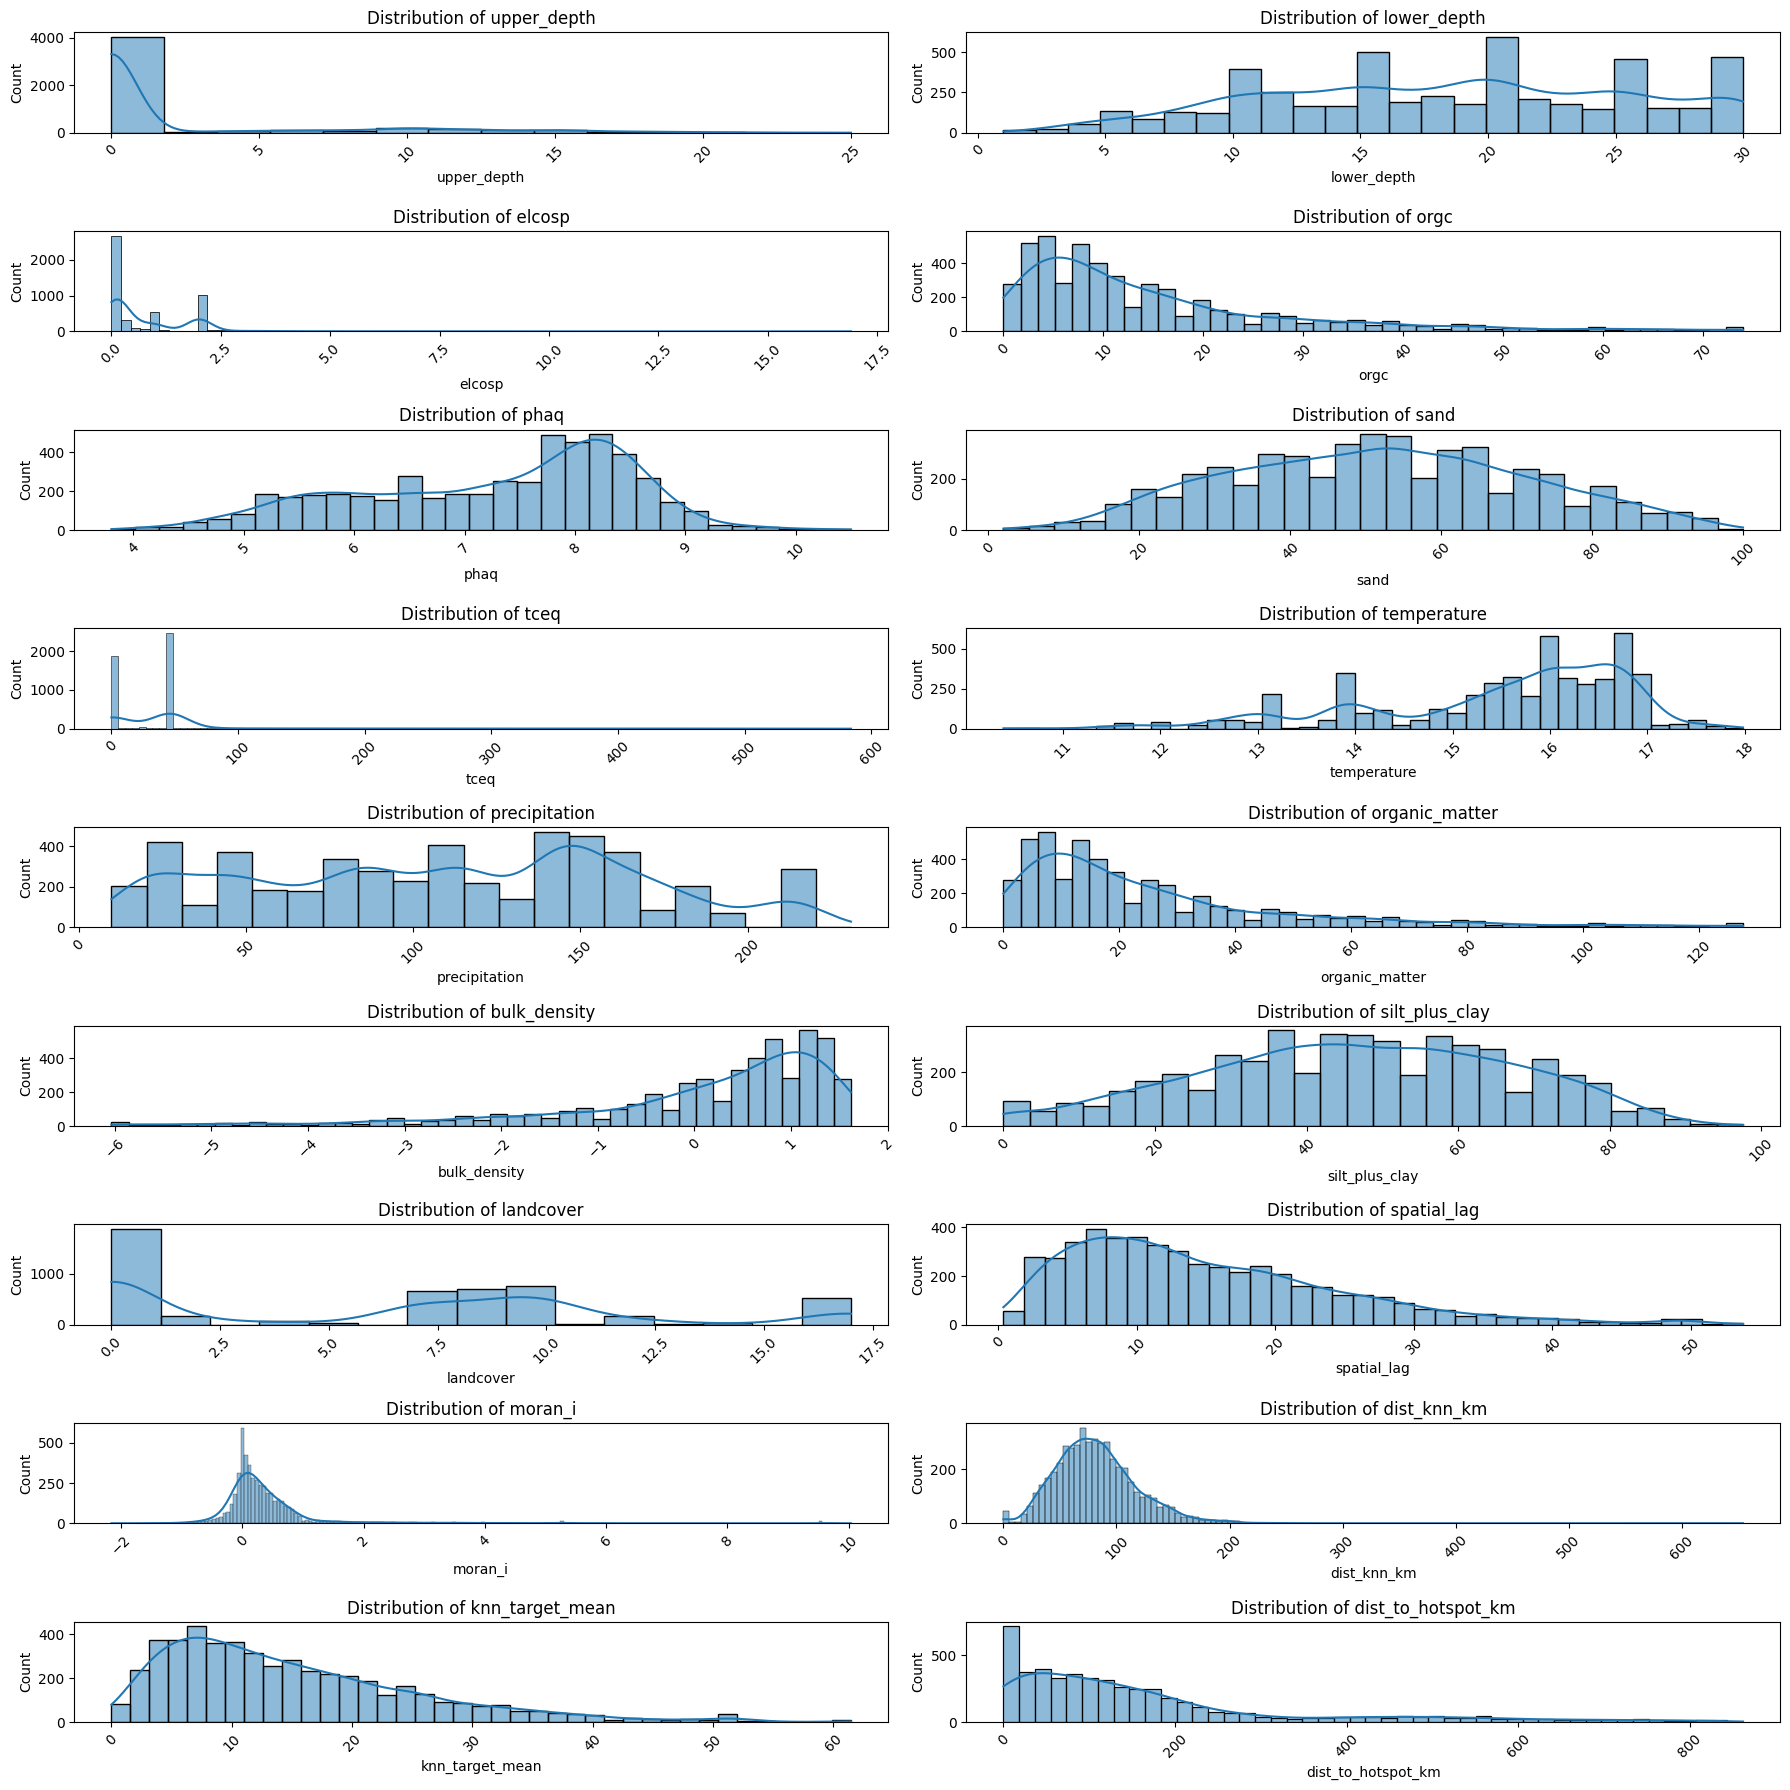

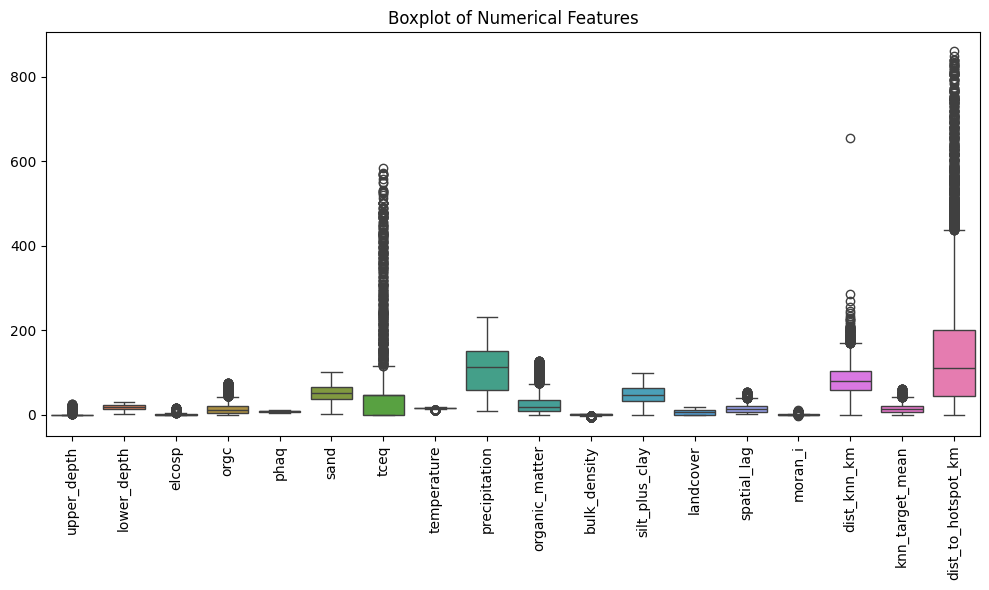

In [8]:
# plot data distribution of each column
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(18, 18))

# Get numerical columns
numeric_cols = gdf.select_dtypes(include=['float64', 'int64']).columns

# Create subplots for each numeric column
n_cols = 2
n_rows = (len(numeric_cols) + 1) // 2
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=gdf, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Create a separate boxplot for outlier visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=gdf[numeric_cols])
plt.xticks(rotation=90)
plt.title('Boxplot of Numerical Features')
plt.tight_layout()
plt.show()

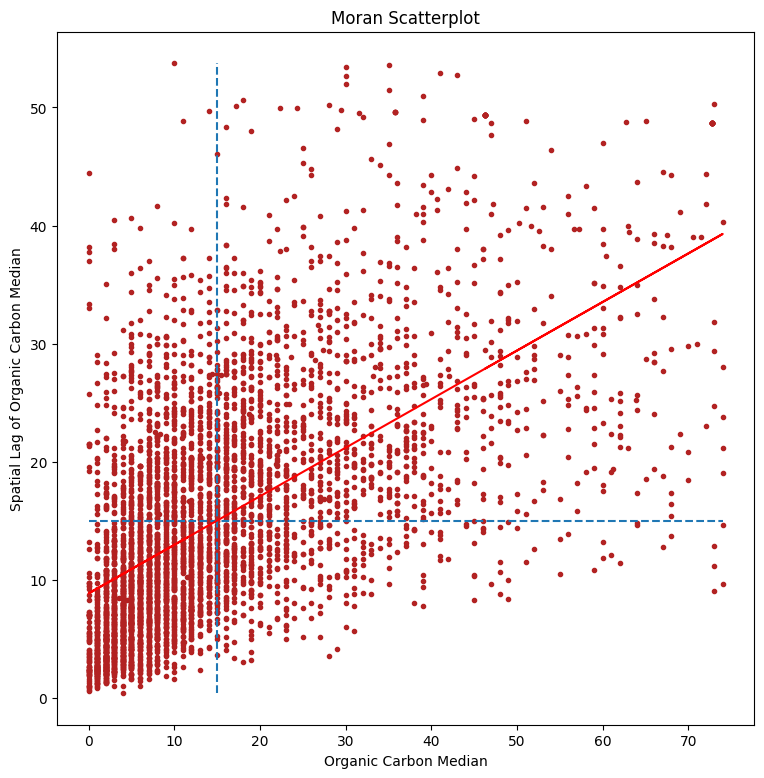

In [9]:
lag_orgc = gdf['spatial_lag']
y = gdf[TARGET_COL]

b, a = np.polyfit(y, lag_orgc, 1)
f, ax = plt.subplots(1, figsize=(9, 9))

plt.plot(y, lag_orgc, '.', color='firebrick')

# dashed vert at mean of the price
plt.vlines(y.mean(), lag_orgc.min(), lag_orgc.max(), linestyle='--')
# dashed horizontal at mean of lagged price
plt.hlines(lag_orgc.mean(), y.min(), y.max(), linestyle='--')

# red line of best fit using global I as slope
plt.plot(y, a + b*y, 'r')
plt.title('Moran Scatterplot')
plt.ylabel('Spatial Lag of Organic Carbon Median')
plt.xlabel('Organic Carbon Median')
plt.show()

In [10]:
def scale_features(gdf, test_size=0.2, random_state=42):
    # deep learning for organic carbon prediction
    X = gdf.drop(columns=['geometry', TARGET_COL])
    y = gdf[TARGET_COL]

    # split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler

def build_model(X_train):
    # build the model
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'), # first hidden layer with 64 neurons
        Dropout(0.2), # add dropout to reduce overfitting
        Dense(32, activation='relu'), # second hidden layer with 32 neurons
        Dropout(0.2), # add dropout to reduce overfitting
        Dense(1) # output layer with 1 neuron
    ])

    # compile the model
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

# scale features
X_train, X_test, y_train, y_test, scalar = scale_features(gdf)
# build the model
model = build_model(X_train)

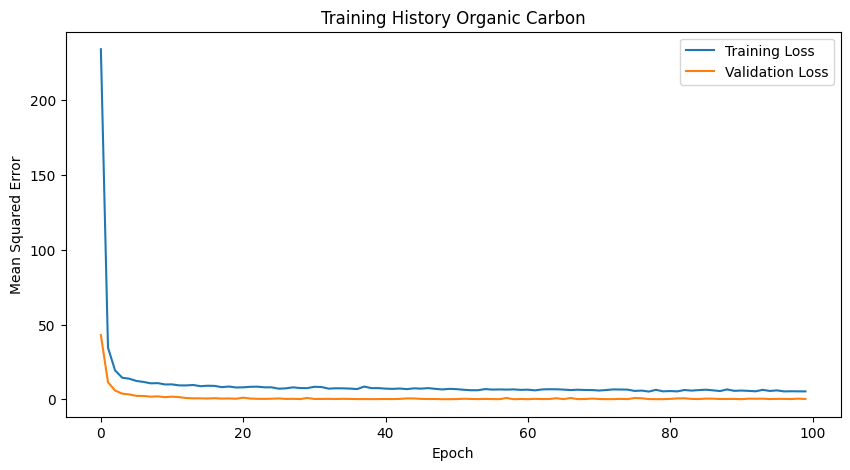

In [11]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=32):
    # train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test), verbose=0)
    return history

# train the model
history = train_model(model, X_train, y_train, X_test, y_test)

# plot the training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training History Organic Carbon')
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, X_test, y_test):
    """
    Evaluate deep learning model performance using multiple metrics.
    Returns dictionary of metrics and predicted values.
    """
    # Get model predictions
    y_pred = model.predict(X_test, verbose=0).flatten()
    
    # Calculate metrics using sklearn functions for better efficiency
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Get model loss
    loss = model.evaluate(X_test, y_test, verbose=0)[0]
    
    # Store metrics in dictionary
    metrics = {
        'loss': loss,
        'mae': mae, 
        'mse': mse,
        'rmse': rmse,
        'r2': r2
    }
    
    # Print formatted results
    print("\nDeep Learning Model Evaluation:")
    print("-" * 30)
    print(f"Mean Squared Error:     {metrics['mse']:.4f}")
    print(f"Root Mean Squared Error: {metrics['rmse']:.4f}")
    print(f"Mean Absolute Error:    {metrics['mae']:.4f}") 
    print(f"R² Score:              {metrics['r2']:.4f}")
    print("-" * 30)
    
    return metrics, y_pred

# Evaluate model and get metrics
metrics, y_pred = evaluate_model(model, X_test, y_test)


Deep Learning Model Evaluation:
------------------------------
Mean Squared Error:     0.2745
Root Mean Squared Error: 0.5239
Mean Absolute Error:    0.4011
R² Score:              0.9986
------------------------------


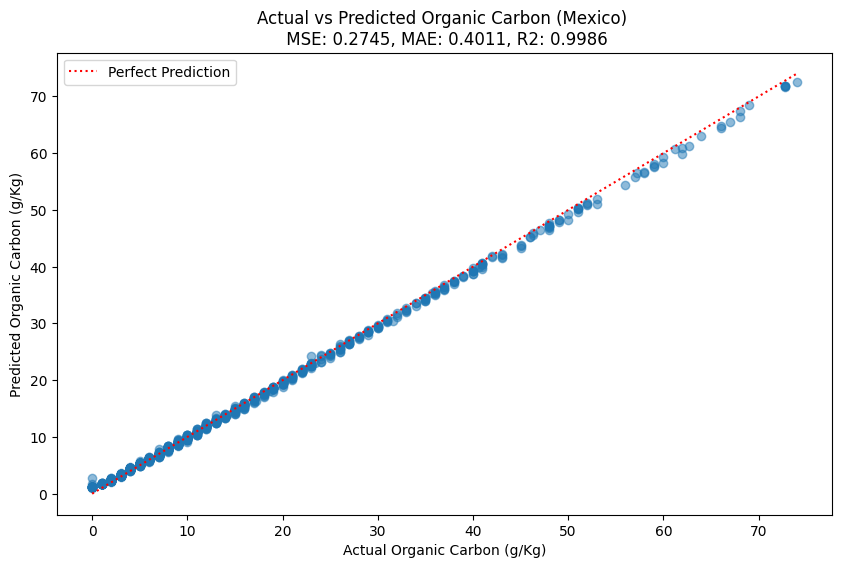

In [13]:
# plot the predictions vs the actual values
def plot_predictions(y_test, y_pred, metrics, country_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r:', label='Perfect Prediction')
    plt.xlabel('Actual Organic Carbon (g/Kg)')
    plt.ylabel('Predicted Organic Carbon (g/Kg)')
    plt.title(f'Actual vs Predicted Organic Carbon ({country_name}) \n MSE: {metrics['mse']:.4f}, MAE: {metrics['mae']:.4f}, R2: {metrics['r2']:.4f}')
    plt.legend()
    plt.show()

# plot the predictions vs the actual values
plot_predictions(y_test, y_pred, metrics, 'Mexico')

In [14]:
import joblib
model_path = "D:/tierra/models/orgc_dl_model.pkl"
scalar_path = "D:/tierra/models/orgc_dl_scalar.pkl"

# Save the model
joblib.dump(model, model_path)
# save the scalar
joblib.dump(scalar, scalar_path)
print("Model saved successfully")

# save the preprocessed data
gdf.to_csv("D:/tierra/datasets/dl_mexico_dataset.csv")

Model saved successfully


# Testing and Evaluation of the model for different countries


In [15]:
# load the model and sclar
MODEL = joblib.load(model_path)
SCALAR = joblib.load(scalar_path)

In [16]:
def load_test_dataset(dataset, mex_dataset):
    # Get feature columns and ensure they exist in UK data
    feature_columns = mex_dataset.columns
    for col in feature_columns:
        if col not in dataset.columns:
            dataset[col] = 0
    
    # preprocess the dataset
    dataset['date'] = pd.to_datetime(dataset['date'], format='%Y-%m-%d', errors='coerce')

    # filter columns and rows
    dataset = (dataset.dropna(subset=[TARGET_COL])
                    .drop_duplicates())

    # add derived features
    dataset = om_bd_columns(dataset)
    dataset = silt_plus_clay_columns(dataset)

    # handle numeric columns
    df = dataset[feature_columns].copy()
    
    # fill missing numeric values with zero
    df = df.fillna(0)

    # add location and categorical columns
    df = pd.concat([
        df,
        dataset[LAT_LONG_COLS]
    ], axis=1)

    # replace NaN landcover with 0
    df['landcover'] = df['landcover'].fillna(0)

    # convert to geodataframe
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))

    # drop latitude and longitude
    gdf = gdf.drop(columns=['latitude', 'longitude'])

    print("-"*30)
    print(f"Feature columns: {feature_columns}")
    print(f"Dataset columns: {gdf.columns}")
    print(f"Data after pre-processing: {gdf.shape}")
    print("-"*30)

    # add spatial features
    gdf = spatial_features(gdf)

    return gdf

def test_model(test_gdf, model, scalar, country_name):
    # drop columns
    test_features = test_gdf.drop(columns=['geometry', TARGET_COL])
    # Scale features
    test_gdf_scaled = scalar.transform(test_features)
    # split into features and target
    X_test = test_gdf_scaled
    y_test = test_gdf[TARGET_COL]
    # evaluate the model
    metrics, y_pred = evaluate_model(model, X_test, y_test)
    # plot the predictions vs the actual values
    plot_predictions(y_test, y_pred, metrics, country_name)

## UK dataset

------------------------------
Feature columns: Index(['upper_depth', 'lower_depth', 'elcosp', 'orgc', 'phaq', 'sand', 'tceq',
       'temperature', 'precipitation', 'organic_matter', 'bulk_density',
       'silt_plus_clay', 'landcover', 'geometry', 'spatial_lag', 'moran_i',
       'dist_knn_km', 'knn_target_mean', 'dist_to_hotspot_km'],
      dtype='object')
Dataset columns: Index(['upper_depth', 'lower_depth', 'elcosp', 'orgc', 'phaq', 'sand', 'tceq',
       'temperature', 'precipitation', 'organic_matter', 'bulk_density',
       'silt_plus_clay', 'landcover', 'geometry', 'spatial_lag', 'moran_i',
       'dist_knn_km', 'knn_target_mean', 'dist_to_hotspot_km'],
      dtype='object')
Data after pre-processing: (466, 19)
------------------------------

Deep Learning Model Evaluation:
------------------------------
Mean Squared Error:     9.9982
Root Mean Squared Error: 3.1620
Mean Absolute Error:    1.8734
R² Score:              0.9995
------------------------------


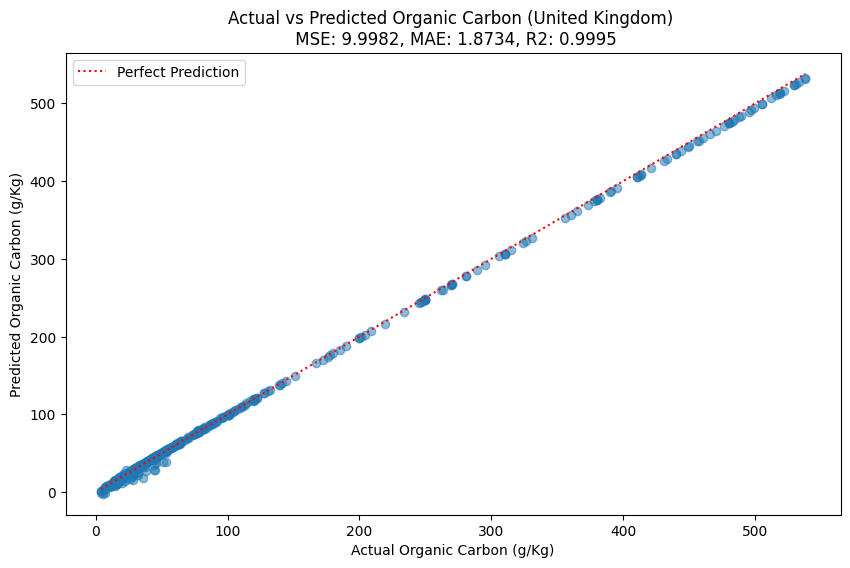

,upper_depth,lower_depth,elcosp,orgc,phaq,sand,tceq,temperature,precipitation,organic_matter,bulk_density,silt_plus_clay,landcover,geometry,spatial_lag,moran_i,dist_knn_km,knn_target_mean,dist_to_hotspot_km
18,0,6,0,100.0,0.0,0.0,0.0,0.0,0.0,172.400,-8.72400,0.0,0.0,POINT (0.7669 51.3911),56.640000,0.038441,16.895902,31.00,311.737148
67,8,25,0,28.0,0.0,0.0,0.0,0.0,0.0,48.272,-1.27632,0.0,0.0,POINT (0.05 51.66667),71.944444,0.176460,6.896713,110.60,254.996881
95,0,23,0,9.0,0.0,0.0,0.0,0.0,0.0,15.516,0.68904,0.0,0.0,POINT (0.6811 52.4222),33.000000,0.416939,154.922996,13.40,287.178295
102,0,20,0,18.0,0.0,0.0,0.0,0.0,0.0,31.032,-0.24192,0.0,0.0,POINT (1.2886 52.4022),15.300000,0.464717,82.528750,10.00,328.332151
112,0,12,0,365.0,0.0,0.0,0.0,0.0,0.0,629.260,-36.13560,0.0,0.0,POINT (-1.7889 53.5006),74.384615,-0.487548,222.573456,42.20,131.050533
126,0,10,0,82.0,0.0,0.0,0.0,0.0,0.0,141.368,-6.86208,0.0,0.0,POINT (-1.08333 53.1167),34.666667,0.123490,9.602044,31.80,166.481674
144,0,26,0,20.0,0.0,0.0,0.0,0.0,0.0,34.480,-0.44880,0.0,0.0,POINT (-1.1747 54.2206),154.316667,-0.188142,251.861756,191.12,208.662481
151,0,27,0,22.0,0.0,0.0,0.0,0.0,0.0,37.928,-0.65568,0.0,0.0,POINT (-0.4822 53.8625),149.100000,-0.160505,210.848154,172.52,226.044482
154,0,18,0,41.0,0.0,0.0,0.0,0.0,0.0,70.684,-2.62104,0.0,0.0,POINT (-1.7753 53.1297),65.090909,0.174274,46.471226,42.60,120.618606
169,10,25,0,4.0,0.0,0.0,0.0,0.0,0.0,6.896,1.20624,0.0,0.0,POINT (-0.91667 53.25),44.388889,0.375169,18.525444,60.20,179.078412


In [17]:
# United Kingdom dataset
# load and preprocess dataset
uk_dataset = pd.read_csv("D:/tierra/data/United Kingdom_wosis_merged_all.csv")

uk_gdf = load_test_dataset(uk_dataset, gdf)

test_model(uk_gdf, MODEL, SCALAR, "United Kingdom")

# save dataset
uk_gdf.to_csv("D:/tierra/datasets/dl_uk_dataset.csv")

uk_gdf.head(10)

------------------------------
Feature columns: Index(['upper_depth', 'lower_depth', 'elcosp', 'orgc', 'phaq', 'sand', 'tceq',
       'temperature', 'precipitation', 'organic_matter', 'bulk_density',
       'silt_plus_clay', 'landcover', 'geometry', 'spatial_lag', 'moran_i',
       'dist_knn_km', 'knn_target_mean', 'dist_to_hotspot_km'],
      dtype='object')
Dataset columns: Index(['upper_depth', 'lower_depth', 'elcosp', 'orgc', 'phaq', 'sand', 'tceq',
       'temperature', 'precipitation', 'organic_matter', 'bulk_density',
       'silt_plus_clay', 'landcover', 'geometry', 'spatial_lag', 'moran_i',
       'dist_knn_km', 'knn_target_mean', 'dist_to_hotspot_km'],
      dtype='object')
Data after pre-processing: (702, 19)
------------------------------

Deep Learning Model Evaluation:
------------------------------
Mean Squared Error:     2.2827
Root Mean Squared Error: 1.5108
Mean Absolute Error:    1.2857
R² Score:              0.9979
------------------------------


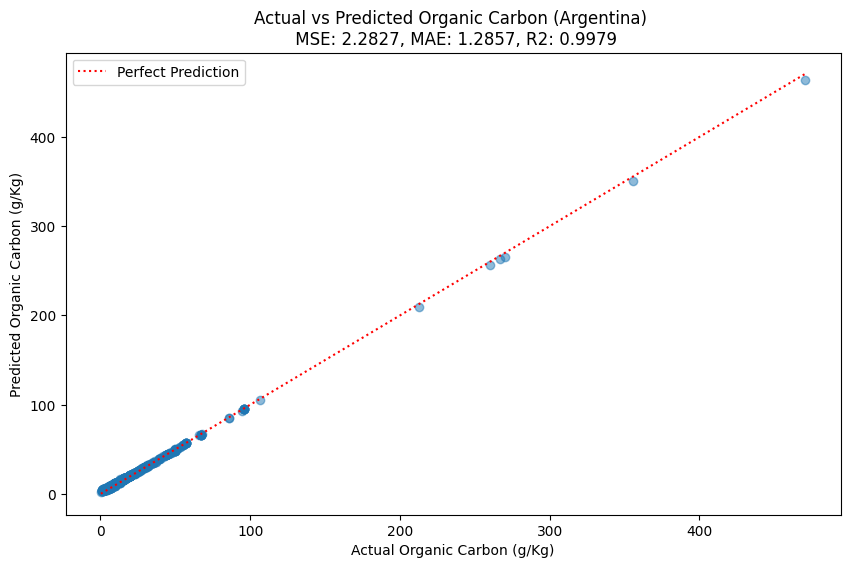

,upper_depth,lower_depth,elcosp,orgc,phaq,sand,tceq,temperature,precipitation,organic_matter,bulk_density,silt_plus_clay,landcover,geometry,spatial_lag,moran_i,dist_knn_km,knn_target_mean,dist_to_hotspot_km
0,0,30,0,20.300000,0.0,0.0,0.0,0,0,34.997200,-0.479832,0.0,0,POINT (-60.82222 -34.22639),11.275000,0.001993,211.187358,12.9800,494.864002
2,0,30,0,6.554000,0.0,0.0,0.0,0,0,11.299096,0.942054,0.0,0,POINT (-72.57507 -48.48055),27.376001,-0.089337,65.865524,26.6684,219.525517
6,0,30,0,28.826000,0.0,0.0,0.0,0,0,49.696024,-1.361761,0.0,0,POINT (-72.3006 -48.29167),21.209600,0.005259,92.665341,20.5204,243.431632
8,0,10,0,35.300000,0.0,0.0,0.0,0,0,60.857200,-2.031432,0.0,0,POINT (-58.26667 -37.85),38.664286,0.250081,0.000000,27.6400,133.611402
12,0,30,0,15.892000,0.0,0.0,0.0,0,0,27.397808,-0.023868,0.0,0,POINT (-72.25719 -48.31817),13.329778,0.031189,91.259403,23.1072,241.171335
18,0,7,0,9.700000,0.0,0.0,0.0,0,0,16.722800,0.616632,0.0,0,POINT (-72.8175 -49.666),15.242462,0.053480,481.761886,15.3088,86.550409
25,0,30,0,47.038002,0.0,0.0,0.0,0,0,81.093515,-3.245611,0.0,0,POINT (-72.56667 -48.46548),15.370000,-0.127732,64.679085,18.5716,221.264783
32,15,28,0,14.700000,0.0,0.0,0.0,0,0,25.342800,0.099432,0.0,0,POINT (-58.26667 -37.85),40.135714,-0.106737,0.000000,27.6400,133.611402
39,0,30,0,22.388000,0.0,0.0,0.0,0,0,38.596912,-0.695815,0.0,0,POINT (-72.26925 -48.31624),18.482667,-0.003552,88.786399,21.8080,241.202259
50,0,10,0,1.300000,0.0,0.0,0.0,0,0,2.241200,1.485528,0.0,0,POINT (-64.5 -35.5),9.766667,0.193285,188.289650,10.9200,557.753337


In [20]:
# Argentina dataset
# load and preprocess dataset
arg_dataset = pd.read_csv("D:/tierra/data/Argentina_wosis_merged.csv")

arg_gdf = load_test_dataset(arg_dataset, gdf)

test_model(arg_gdf, MODEL, SCALAR, "Argentina")

# save dataset
arg_gdf.to_csv("D:/tierra/datasets/arg_dataset.csv")

arg_gdf.head(10)

------------------------------
Feature columns: Index(['upper_depth', 'lower_depth', 'elcosp', 'orgc', 'phaq', 'sand', 'tceq',
       'temperature', 'precipitation', 'organic_matter', 'bulk_density',
       'silt_plus_clay', 'landcover', 'geometry', 'spatial_lag', 'moran_i',
       'dist_knn_km', 'knn_target_mean', 'dist_to_hotspot_km'],
      dtype='object')
Dataset columns: Index(['upper_depth', 'lower_depth', 'elcosp', 'orgc', 'phaq', 'sand', 'tceq',
       'temperature', 'precipitation', 'organic_matter', 'bulk_density',
       'silt_plus_clay', 'landcover', 'geometry', 'spatial_lag', 'moran_i',
       'dist_knn_km', 'knn_target_mean', 'dist_to_hotspot_km'],
      dtype='object')
Data after pre-processing: (817, 19)
------------------------------

Deep Learning Model Evaluation:
------------------------------
Mean Squared Error:     5.5752
Root Mean Squared Error: 2.3612
Mean Absolute Error:    2.2419
R² Score:              0.8954
------------------------------


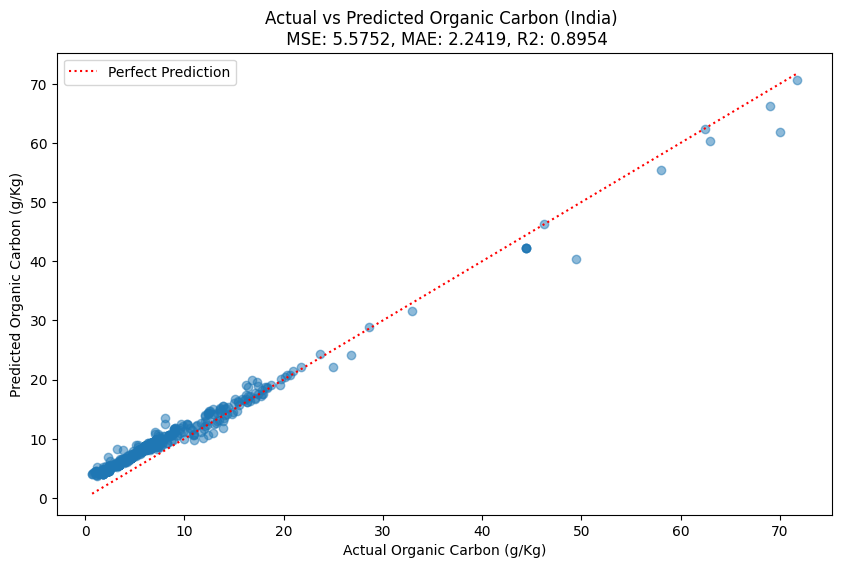

,upper_depth,lower_depth,elcosp,orgc,phaq,sand,tceq,temperature,precipitation,organic_matter,bulk_density,silt_plus_clay,landcover,geometry,spatial_lag,moran_i,dist_knn_km,knn_target_mean,dist_to_hotspot_km
2,0,9,0,1.1,0.0,0.0,0.0,0,0,1.8964,1.506216,0.0,0,POINT (72.83333 26.08333),2.470000,0.479400,426.636576,3.18,734.555233
4,15,30,0,2.3,0.0,0.0,0.0,0,0,3.9652,1.382088,0.0,0,POINT (80.75 26.66667),4.623077,0.194914,850.627503,3.24,249.880673
9,0,15,0,3.8,0.0,0.0,0.0,0,0,6.5512,1.226928,0.0,0,POINT (80.75 26.66667),4.507692,0.137895,850.627503,3.24,249.880673
63,0,13,0,3.2,0.0,0.0,0.0,0,0,5.5168,1.288992,0.0,0,POINT (72 24.5),5.712381,0.081399,1083.088080,2.66,909.430410
67,0,23,0,16.4,0.0,0.0,0.0,0,0,28.2736,-0.076416,0.0,0,POINT (73.5 21),5.754808,-0.202228,683.031009,5.78,1122.589172
69,0,18,0,16.8,0.0,0.0,0.0,0,0,28.9632,-0.117792,0.0,0,POINT (84.5 26),4.569231,-0.430828,895.228992,3.18,131.101865
77,0,29,0,8.6,0.0,0.0,0.0,0,0,14.8264,0.730416,0.0,0,POINT (78 30.25),13.010000,0.196048,138.993850,12.86,117.699000
79,0,8,0,46.2,0.0,0.0,0.0,0,0,79.6488,-3.158928,0.0,0,POINT (77.8667 30.7),6.783333,-0.078521,367.165221,11.10,157.630549
81,1,18,0,17.3,0.0,0.0,0.0,0,0,29.8252,-0.169512,0.0,0,POINT (85.0667 20.8),5.392857,-0.291950,518.192592,7.24,345.351895
82,0,15,0,1.2,0.0,0.0,0.0,0,0,2.0688,1.495872,0.0,0,POINT (78.15 26.2),5.836000,0.112341,587.022332,3.12,403.065417


In [19]:
# India dataset
# load and preprocess dataset
ind_dataset = pd.read_csv("D:/tierra/outputs/India_wosis_merged.csv")

ind_gdf = load_test_dataset(ind_dataset, gdf)

test_model(ind_gdf, MODEL, SCALAR, "India")

# save dataset
ind_gdf.to_csv("D:/tierra/datasets/dl_ind_dataset.csv")

ind_gdf.head(10)